In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_core.prompts import PromptTemplate

/home/narendra/Agentic AI/agentenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [3]:
class LLMState(TypedDict):
    question: str
    answer: str

In [4]:
def qa_llm(state: LLMState) -> LLMState:
    question = state["question"]

    template = PromptTemplate(
        template="answer question politely :{question}",
        input_variables=["question"],
        validate_template=True,
    )
    prompt = template.invoke({"question": question})

    result = model.invoke(prompt)

    state["answer"] = result.content

    return state

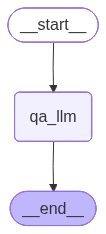

In [5]:
graph = StateGraph(LLMState)

# add node
graph.add_node("qa_llm", qa_llm)

# edge
graph.add_edge(START, "qa_llm")
graph.add_edge("qa_llm", END)


workflow = graph.compile()

workflow

In [6]:
input_state = {"question": "any topic in finance"}

final_state = workflow.invoke(input_state)
final_state

{'question': 'any topic in finance',
 'answer': "Certainly! I'd be absolutely delighted to help you with any question you might have about finance.\n\nFinance is a vast and fascinating field, ranging from personal budgeting to global markets, and everything in between. Please don't hesitate to ask!\n\nWhether it's a fundamental concept you're curious about, a specific investment vehicle, economic trends, or even just understanding a term you've come across, I'll do my very best to provide a clear, helpful, and polite answer.\n\nFor example, you might ask about:\n*   **Personal Finance:** Budgeting, saving strategies, investing for retirement, understanding credit scores, mortgages, or managing debt.\n*   **Investing:** How stocks or bonds work, mutual funds, diversification, risk management, or market trends.\n*   **Corporate Finance:** How companies raise capital, financial statements, or company valuation.\n*   **Economics:** Inflation, interest rates, central banks, or economic indi